# KIND model training

In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries --!

import numpy as np
import torch
import matplotlib.pyplot as plt

import kind
import duffing
import util_data

In [2]:
# --! specify kind arguments --!

parser = kind.create_args_parser()

args = parser.parse_args(
    args=[
        '--file_dir', '../../data/duffing',
        '--file_name', 'duffing',
        '--data_nsample_nom', '253',
        '--data_nsample_exc', '460',
        '--feature_ndim', '4',
        '--target_ndim', '2',
        '--data_train_size', '0.9',

        '--back_nsample', '64',
        '--fore_nsample', '32',

        '--batch_size', '64',
        '--learning_rate', '0.002',
        '--weight_decay', '0.000001',
        '--nepoch', '1000',
        '--patience', '100',
        '--checkpoints', '../../models/duffing',

        '--rez_nsample_nom', '32',
        '--rez_nsample_exc', '16',
        '--embed_nom', '{"sin": 6, "cos": 6}',
        '--embed_exc', '{"data": 12}',
    ]
)

setpoint = [1.0, 0.0]

In [3]:
model = kind.model(args)

dataset = duffing.dataset(
    args.file_dir, args.file_name, args.file_index, args.file_ext,
    args.data_nsample_nom, args.data_nsample_exc,
    (args.data_train_size, args.data_test_size),
    args.batch_size, (args.back_nsample, args.fore_nsample), setpoint, load_normalized=True)

training = kind.training(model)

## Train nominal model

In [4]:
model.train()
training.fit(dataset)

>>> training nominal mean >>>
	epoch 1 losses: train=1.252205, valid=1.021039, test=1.243225
	validation loss decreased (inf -> 1.021039), saving model ...
	epoch 2 losses: train=1.142208, valid=0.988248, test=1.203865
	validation loss decreased (1.021039 -> 0.988248), saving model ...
	epoch 3 losses: train=1.120124, valid=0.949447, test=1.157840
	validation loss decreased (0.988248 -> 0.949447), saving model ...
	epoch 4 losses: train=1.108785, valid=0.903339, test=1.098445
	validation loss decreased (0.949447 -> 0.903339), saving model ...
	epoch 5 losses: train=1.008732, valid=0.850366, test=1.028229
	validation loss decreased (0.903339 -> 0.850366), saving model ...
	epoch 6 losses: train=0.894452, valid=0.805374, test=0.965874
	validation loss decreased (0.850366 -> 0.805374), saving model ...
	epoch 7 losses: train=0.832470, valid=0.804192, test=0.960871
	validation loss decreased (0.805374 -> 0.804192), saving model ...
	epoch 8 losses: train=0.808343, valid=0.777428, test=0.92

In [5]:
model.eval()
data_loader, _, _ = dataset.load(data_type='nom')

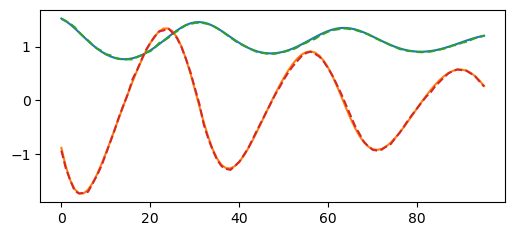

In [6]:
jdata = 15

with torch.no_grad():
    for back, fore in data_loader:
        true = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        mean_nom = model_o.mean_nom

        plt.figure(figsize=(6,2.5))
        plt.plot(true[jdata, :, :2])
        plt.plot(mean_nom[0, :, :2], linestyle='dashed')

        plt.show()

        break


## Train nominal model's uncertainty

In [7]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training nominal uncertainty >>>
	epoch 1 losses: train=1.714604, valid=1.237757, test=2.834431
	validation loss decreased (inf -> 1.237757), saving model ...
	epoch 2 losses: train=1.787068, valid=1.193138, test=2.766544
	validation loss decreased (1.237757 -> 1.193138), saving model ...
	epoch 3 losses: train=1.561559, valid=1.145966, test=2.669300
	validation loss decreased (1.193138 -> 1.145966), saving model ...
	epoch 4 losses: train=1.537068, valid=1.026877, test=2.374958
	validation loss decreased (1.145966 -> 1.026877), saving model ...
	epoch 5 losses: train=1.295425, valid=0.956835, test=2.079974
	validation loss decreased (1.026877 -> 0.956835), saving model ...
	epoch 6 losses: train=1.395342, valid=0.867895, test=1.842606
	validation loss decreased (0.956835 -> 0.867895), saving model ...
	epoch 7 losses: train=1.221287, valid=0.861623, test=1.592458
	validation loss decreased (0.867895 -> 0.861623), saving model ...
	epoch 8 losses: train=1.140876, valid=0.920410, te

In [8]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

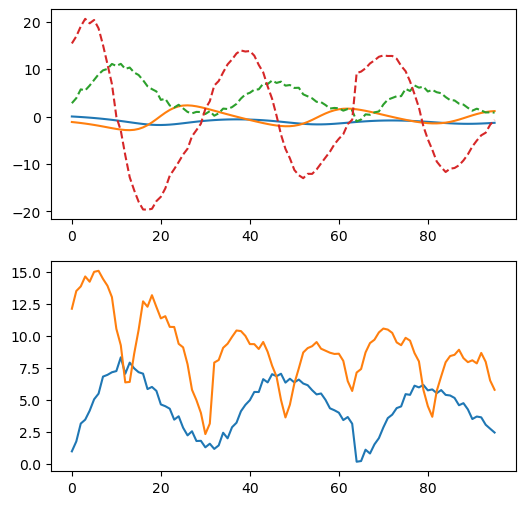

In [9]:
jdata = 5

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        stat = model_o.mean_nom
        zeta_nom = model_o.zeta_nom

        plt.figure(figsize=(6,6))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :2])
        plt.plot(stat[0, :, :2], linestyle='dashed')

        plt.subplot(2,1,2)
        plt.plot(zeta_nom[0, :, :2])

        plt.show()

        break


## Train excursion model

In [10]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training excursion mean >>>
	epoch 1 losses: train=0.917151, valid=0.747967, test=0.792560
	validation loss decreased (inf -> 0.747967), saving model ...
	epoch 2 losses: train=0.877515, valid=0.686777, test=0.797389
	validation loss decreased (0.747967 -> 0.686777), saving model ...
	epoch 3 losses: train=0.854846, valid=0.597779, test=0.798784
	validation loss decreased (0.686777 -> 0.597779), saving model ...
	epoch 4 losses: train=0.738807, valid=0.482586, test=0.678380
	validation loss decreased (0.597779 -> 0.482586), saving model ...
	epoch 5 losses: train=0.665675, valid=0.449670, test=0.611693
	validation loss decreased (0.482586 -> 0.449670), saving model ...
	epoch 6 losses: train=0.622133, valid=0.425770, test=0.570324
	validation loss decreased (0.449670 -> 0.425770), saving model ...
	epoch 7 losses: train=0.569150, valid=0.403305, test=0.528821
	validation loss decreased (0.425770 -> 0.403305), saving model ...
	epoch 8 losses: train=0.560628, valid=0.370057, test=0.

In [11]:
model.eval()
_, _, data_loader = dataset.load(data_type='exc')

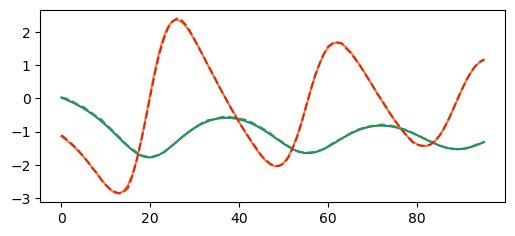

In [12]:
jdata = 7

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        stat = model_o.mean_exc

        plt.figure(figsize=(6,2.5))
        plt.plot(truth[jdata, :, :2])
        plt.plot(stat[0, :, :2], linestyle='dashed')

        plt.show()

        break

## Train excursion model's uncertainty

In [13]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training excursion uncertainty >>>
	epoch 1 losses: train=0.441678, valid=0.554771, test=0.118716
	validation loss decreased (inf -> 0.554771), saving model ...
	epoch 2 losses: train=0.426633, valid=0.526401, test=0.117593
	validation loss decreased (0.554771 -> 0.526401), saving model ...
	epoch 3 losses: train=0.403362, valid=0.506484, test=0.125535
	validation loss decreased (0.526401 -> 0.506484), saving model ...
	epoch 4 losses: train=0.405427, valid=0.500024, test=0.126999
	validation loss decreased (0.506484 -> 0.500024), saving model ...
	epoch 5 losses: train=0.396289, valid=0.499281, test=0.125897
	validation loss decreased (0.500024 -> 0.499281), saving model ...
	epoch 6 losses: train=0.395394, valid=0.499953, test=0.124585
	early stopping counter: 1 out of 100
	epoch 7 losses: train=0.392308, valid=0.499892, test=0.124100
	early stopping counter: 2 out of 100
	epoch 8 losses: train=0.390884, valid=0.499736, test=0.122445
	early stopping counter: 3 out of 100
	epoch 9

In [14]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

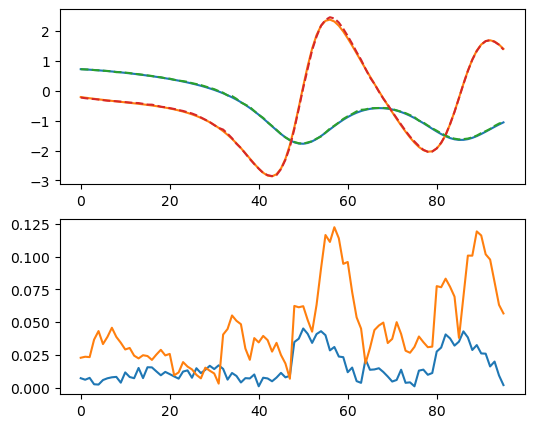

In [15]:
jdata = 5

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        exc = model_o.mean_exc
        exc_u = model_o.zeta_exc

        plt.figure(figsize=(6,5))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :2])
        plt.plot(exc[0, :, :2], linestyle='dashed')

        plt.subplot(2,1,2)
        plt.plot(exc_u[0, :, :2])

        plt.show()

        break

## Evaluate KIND blending

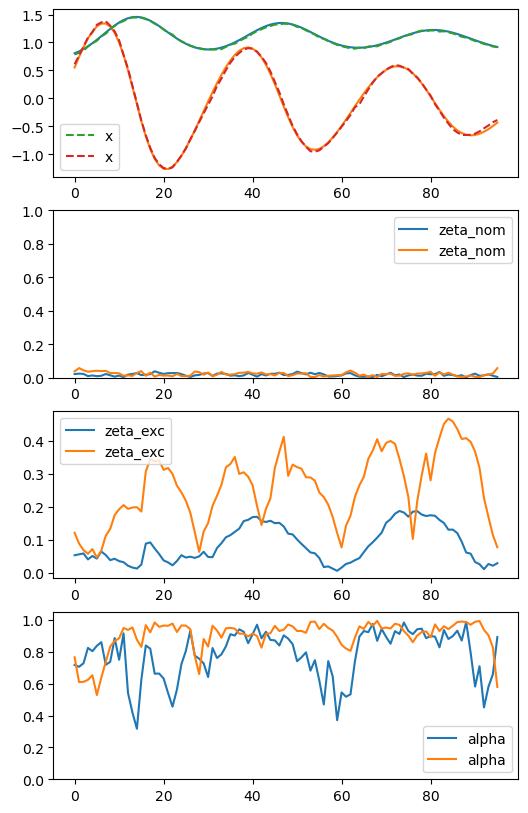

In [16]:
jdata = 4

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        pre = model_o.blend
        u_nom = model_o.zeta_nom
        u_exc = model_o.zeta_exc
        alpha = model_o.alpha

        plt.figure(figsize=(6,10))

        plt.subplot(4,1,1)
        plt.plot(truth[jdata, :, :2])
        plt.plot(pre[0, :, :2], linestyle='dashed', label='x')
        plt.legend()

        plt.subplot(4,1,2)
        plt.plot(u_nom[0, :, :2], label='zeta_nom')
        plt.ylim((0,1))
        plt.legend()

        plt.subplot(4,1,3)
        plt.plot(u_exc[0, :, :2], label='zeta_exc')
        plt.legend()

        plt.subplot(4,1,4)
        plt.plot(alpha[0, :, :2], label='alpha')
        plt.ylim((0.0, 1.05))
        plt.legend()

        plt.show()

        break